<a href="https://colab.research.google.com/github/tonmoyDatta/Machine_Learning/blob/main/xss_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
import os

# Install Kaggle API client if not already installed
!pip install -q kaggle

# Ensure kaggle.json is in the correct directory for Colab
# If you haven't uploaded it, you'll need to do so:
# from google.colab import files
# files.upload() # Then upload your kaggle.json file

# Create a directory for Kaggle and move the kaggle.json file
# This assumes kaggle.json has been uploaded to the Colab environment
# If it's already set up, these lines can be skipped or commented out
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the dataset
dataset_name = "syedsaqlainhussain/cross-site-scripting-xss-dataset-for-deep-learning"
!kaggle datasets download -d {dataset_name}

# Unzip the dataset
# Assuming the downloaded file is named after the dataset (e.g., cross-site-scripting-xss-dataset-for-deep-learning.zip)
import zipfile
import os

zip_file_path = "cross-site-scripting-xss-dataset-for-deep-learning.zip"
extract_path = "./xss_dataset"

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f"Dataset extracted to: {extract_path}")
print("Files in extracted directory:")
print(os.listdir(extract_path))

# Load the dataset into a pandas DataFrame
# Assuming the main data file is 'XSS_dataset.csv' based on typical Kaggle datasets
# You might need to adjust the filename if it's different after extraction
try:
    # Check for common CSV filenames
    csv_files = [f for f in os.listdir(extract_path) if f.endswith('.csv')]
    if not csv_files:
        raise FileNotFoundError("No CSV files found in the extracted directory.")

    # Try to find a file that looks like the main dataset
    # Prioritize 'XSS_dataset.csv' if it exists
    data_file = None
    if 'XSS_dataset.csv' in csv_files:
        data_file = 'XSS_dataset.csv'
    elif 'XSS_dataset_new.csv' in csv_files:
        data_file = 'XSS_dataset_new.csv'
    else:
        data_file = csv_files[0] # Fallback to the first CSV found

    df = pd.read_csv(os.path.join(extract_path, data_file))
    print("Dataset loaded successfully!")
    print(df.head())
    print(df.info())
except Exception as e:
    print(f"Error loading dataset: {e}")
    print("Please check the extracted files and adjust the loading path/filename if necessary.")
    print("Available files in the extracted directory:", os.listdir(extract_path))

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/syedsaqlainhussain/cross-site-scripting-xss-dataset-for-deep-learning
License(s): unknown
100% 390k/390k [00:00<00:00, 118MB/s]

Dataset extracted to: ./xss_dataset
Files in extracted directory:
['XSS_dataset.csv']
Dataset loaded successfully!
   Unnamed: 0                                           Sentence  Label
0           0  <li><a href="/wiki/File:Socrates.png" class="i...      0
1           1               <tt onmouseover="alert(1)">test</tt>      1
2           2  \t </span> <span class="reference-text">Steeri...      0
3           3  \t </span> <span class="reference-text"><cite ...      0
4           4  \t </span>. <a href="/wiki/Digital_object_iden...      0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13686 entries, 0 to 13685
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype

In [3]:
df.head()

,Unnamed: 0,Sentence,Label
0,0,"<li><a href=""/wiki/File:Socrates.png"" class=""i...",0
1,1,"<tt onmouseover=""alert(1)"">test</tt>",1
2,2,"\t </span> <span class=""reference-text"">Steeri...",0
3,3,"\t </span> <span class=""reference-text""><cite ...",0
4,4,"\t </span>. <a href=""/wiki/Digital_object_iden...",0


In [4]:
def extract_features(url):
    features = {}

    # Length
    features['url_length'] = len(url)

    # Script tags
    features['script_tag'] = int(bool(re.search(r"<script>", url, re.IGNORECASE)))

    # JS functions
    features['eval'] = int("eval(" in url)
    features['alert'] = int("alert(" in url)

    # Event handlers
    features['onerror'] = int("onerror" in url)
    features['onload'] = int("onload" in url)

    # DOM objects
    features['document_cookie'] = int("document.cookie" in url)
    features['document_location'] = int("document.location" in url)

    # Special characters
    features['special_chars'] = len(re.findall(r"[<>{}();]", url))

    return features

In [6]:
print(df.columns)
df.head()

Index(['Unnamed: 0', 'Sentence', 'Label'], dtype='object')


,Unnamed: 0,Sentence,Label
0,0,"<li><a href=""/wiki/File:Socrates.png"" class=""i...",0
1,1,"<tt onmouseover=""alert(1)"">test</tt>",1
2,2,"\t </span> <span class=""reference-text"">Steeri...",0
3,3,"\t </span> <span class=""reference-text""><cite ...",0
4,4,"\t </span>. <a href=""/wiki/Digital_object_iden...",0


In [7]:
feature_list = df['Sentence'].apply(extract_features)
feature_df = pd.DataFrame(feature_list.tolist())

X = feature_df
y = df['Label']

In [8]:
df = df.drop(columns=['Unnamed: 0'])

In [9]:
print(X.shape)
print(y.value_counts())

(13686, 9)
Label
1    7373
0    6313
Name: count, dtype: int64


In [10]:
def extract_features(text):
    text = str(text).lower()
    features = {}

    # Length
    features['length'] = len(text)

    # HTML tags
    features['script_tag'] = int("<script" in text)
    features['img_tag'] = int("<img" in text)
    features['iframe'] = int("<iframe" in text)

    # JS functions
    features['alert'] = int("alert(" in text)
    features['eval'] = int("eval(" in text)

    # Event handlers
    features['onerror'] = int("onerror" in text)
    features['onload'] = int("onload" in text)
    features['onclick'] = int("onclick" in text)
    features['onmouseover'] = int("onmouseover" in text)

    # DOM objects
    features['document_cookie'] = int("document.cookie" in text)
    features['document_location'] = int("document.location" in text)

    # Special chars
    features['special_chars'] = len(re.findall(r"[<>{}();]", text))

    return features

In [11]:
# Apply feature extraction
feature_list = df['Sentence'].apply(extract_features)

# Convert to DataFrame
feature_df = pd.DataFrame(feature_list.tolist())

# Features and labels
X = feature_df
y = df['Label']

print(X.head())
print(y.head())

   length  script_tag  img_tag  iframe  alert  eval  onerror  onload  onclick  \
0     557           0        1       0      0     0        0       0        0   
1      36           0        0       0      1     0        0       0        0   
2     233           0        0       0      0     0        0       0        0   
3     395           0        0       0      0     0        0       0        0   
4     422           0        0       0      0     0        0       0        0   

   onmouseover  document_cookie  document_location  special_chars  
0            0                0                  0             17  
1            1                0                  0              6  
2            0                0                  0              8  
3            0                0                  0             19  
4            0                0                  0             20  
0    0
1    1
2    0
3    0
4    0
Name: Label, dtype: int64


In [12]:
# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (10948, 13)
X_test shape: (2738, 13)


In [13]:
# Train Decision Tree model
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

# Prediction
y_pred_dt = dt_model.predict(X_test)

# Accuracy
print("Decision Tree Accuracy:")
print(accuracy_score(y_test, y_pred_dt))

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy:
0.9919649379108838

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1263
           1       1.00      0.99      0.99      1475

    accuracy                           0.99      2738
   macro avg       0.99      0.99      0.99      2738
weighted avg       0.99      0.99      0.99      2738



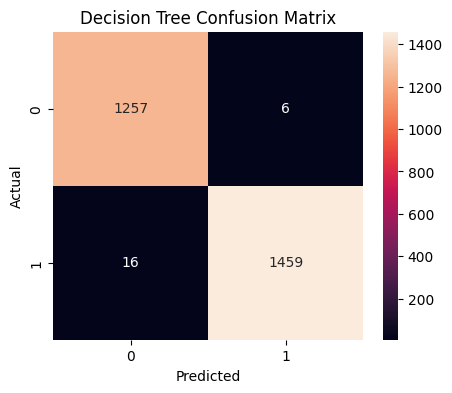

In [14]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [15]:
# Train SVM
svm_model = SVC(kernel='linear')

svm_model.fit(X_train, y_train)

# Prediction
y_pred_svm = svm_model.predict(X_test)

# Evaluation
print("SVM Accuracy:")
print(accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy:
0.9901387874360847

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1263
           1       1.00      0.98      0.99      1475

    accuracy                           0.99      2738
   macro avg       0.99      0.99      0.99      2738
weighted avg       0.99      0.99      0.99      2738



In [16]:
sample_payloads = [
    "<script>alert('XSS')</script>",
    "<img src=x onerror=alert(1)>",
    "hello world",
    "<iframe src='evil.com'></iframe>"
]

sample_features = pd.DataFrame(
    [extract_features(x) for x in sample_payloads]
)

predictions = dt_model.predict(sample_features)

for payload, pred in zip(sample_payloads, predictions):
    print(payload, "->", "XSS" if pred == 1 else "Benign")

<script>alert('XSS')</script> -> XSS
<img src=x onerror=alert(1)> -> XSS
hello world -> Benign
<iframe src='evil.com'></iframe> -> XSS


In [21]:
sample_payloads = [
    "<script\x0Atype=text/javascript>javascript:alert(1);</script>",
    "'`><\x3Cscript>javascript:alert(1)</script>",
    "hello world",
    "<body onkeyup body onkeyup=javascript:javascript:alert(1)></body onkeyup>",
    "<style></style\x0D<img src=about:blank onerror=javascript:alert(1)//></style>"
]

sample_features = pd.DataFrame(
    [extract_features(x) for x in sample_payloads]
)

predictions = dt_model.predict(sample_features)

for payload, pred in zip(sample_payloads, predictions):
    print(payload, "->", "XSS" if pred == 1 else "Benign")

<script
type=text/javascript>javascript:alert(1);</script> -> XSS
'`><<script>javascript:alert(1)</script> -> XSS
hello world -> Benign
<body onkeyup body onkeyup=javascript:javascript:alert(1)></body onkeyup> -> XSS
<img src=about:blank onerror=javascript:alert(1)//></style> -> XSS


In [23]:
sample_payloads = [
    '<iframe xmlns="http://www.w3.org/1999/xhtml" src="javascript:alert(125)"></iframe>',

    "window.open('popup.html','spam'+i,'width=50,height=50');",

    '<!ATTLIST img xmlns CDATA "http://www.w3.org/1999/xhtml" src CDATA "xx:x">',

    '<circle fill="red" r="40"></circle>',

    '<h1>Drop me</h1>',

    '<html:style /><x xlink:href="javascript:alert(68)" xlink:type="simple">XXX</x>',

    '<iframe src="http://example.org/"></iframe>',

    '<svg:circle cx="0.45" cy="0.7" r="0.075" fill="white"/>',

    '<svg:rect x="0.0" y="0.0" width="0.373" height="0.3" fill="white"/>',

    '<xsl:stylesheet id="stylesheet" version="1.0" xmlns:xsl="http://www.w3.org/1999/XSL/Transform">',

    'for (i=1;i<6;i++) {}',

    '<HEAD><META HTTP-EQUIV="CONTENT-TYPE" CONTENT="text/html; charset=UTF-7"></HEAD>+ADw-SCRIPT+AD4-alert("XSS");+ADw-/SCRIPT+AD4-',

    '<OBJECT TYPE="text/x-scriptlet" DATA="http://ha.ckers.org/scriptlet.html"></OBJECT>',

    '<OBJECT TYPE="text/x-scriptlet" DATA="http://xss.rocks/scriptlet.html"></OBJECT>',

    '<script/src=data:text/javascript,alert(1)></script>',

    'javascript:alert(42)',

    'onerror="alert(67)"',

    'onload="alert(2)"',

    '!--" /><script>alert("xss");</script>',

    '" onfocus=alert(document.domain) "> <"',

    '" value=``',

    '"\'%3e%3cscript%3econfirm(42)%3c/script%3e',

    '"\'><script>alert(42)</script>',

    '"\'><style>alert(42)</style>',

    '"\'><script>confirm(42)</script>',

    '"\'><sCriPt>confirm(42)</sCriPt>',

    '"\'><script foo=bar>confirm(42)</script>',

    '"\'><script onlyOpera:-)>alert(42)'
]

# Extract features
sample_features = pd.DataFrame(
    [extract_features(x) for x in sample_payloads]
)

# Predict
predictions = dt_model.predict(sample_features)

# Show results
for payload, pred in zip(sample_payloads, predictions):
    print("="*80)
    print(payload)
    print("Prediction:", "XSS" if pred == 1 else "Benign")

<iframe xmlns="http://www.w3.org/1999/xhtml" src="javascript:alert(125)"></iframe>
Prediction: XSS
window.open('popup.html','spam'+i,'width=50,height=50');
Prediction: Benign
<!ATTLIST img xmlns CDATA "http://www.w3.org/1999/xhtml" src CDATA "xx:x">
Prediction: Benign
<circle fill="red" r="40"></circle>
Prediction: Benign
<h1>Drop me</h1>
Prediction: Benign
<html:style /><x xlink:href="javascript:alert(68)" xlink:type="simple">XXX</x>
Prediction: XSS
<iframe src="http://example.org/"></iframe>
Prediction: XSS
<svg:circle cx="0.45" cy="0.7" r="0.075" fill="white"/>
Prediction: Benign
<svg:rect x="0.0" y="0.0" width="0.373" height="0.3" fill="white"/>
Prediction: Benign
<xsl:stylesheet id="stylesheet" version="1.0" xmlns:xsl="http://www.w3.org/1999/XSL/Transform">
Prediction: Benign
for (i=1;i<6;i++) {}
Prediction: Benign
<HEAD><META HTTP-EQUIV="CONTENT-TYPE" CONTENT="text/html; charset=UTF-7"></HEAD>+ADw-SCRIPT+AD4-alert("XSS");+ADw-/SCRIPT+AD4-
Prediction: XSS
<OBJECT TYPE="text/x-scri